In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv("../data/customer_churn_dataset-training-master.csv")

In [5]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [6]:
df.shape

(440833, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [8]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df[df.isnull().any(axis=1)]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df = df.dropna()

In [12]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [13]:
df.shape

(440832, 12)

In [14]:
df["Churn"].unique()

array([1., 0.])

In [15]:
df["Churn"].value_counts()

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

In [16]:
df["Churn"].value_counts(normalize=True) * 100

Churn
1.0    56.71072
0.0    43.28928
Name: proportion, dtype: float64

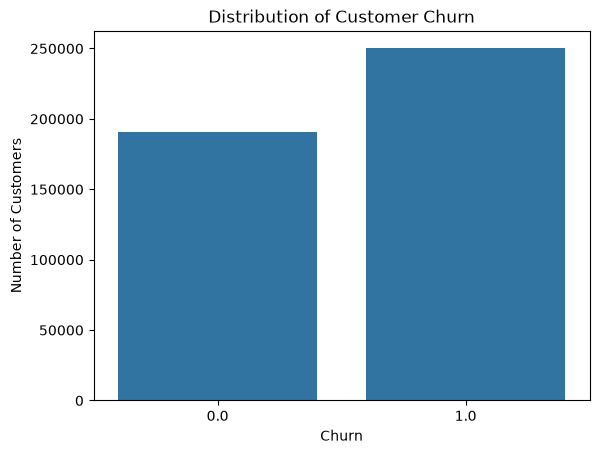

In [17]:
sns.countplot(data=df, x="Churn")
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [18]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [19]:
categorical_columns = [
    "Gender",
    "Subscription Type",
    "Contract Length"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Gender ---
Gender
Male      250252
Female    190580
Name: count, dtype: int64

--- Subscription Type ---
Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

--- Contract Length ---
Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64


In [20]:
df = df.drop(columns=["CustomerID"])

In [21]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [22]:
df.groupby("Churn").mean(numeric_only=True)

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
Churn,,,,,,,
0.0,36.262973,32.281754,16.260552,1.586418,10.015500,749.953111,13.008804
1.0,41.747263,30.473598,15.461658,5.144861,15.217729,541.285528,15.604546


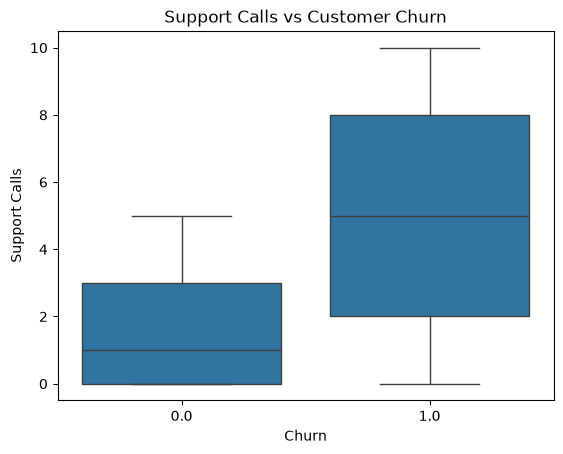

In [23]:
sns.boxplot(data=df, x="Churn", y="Support Calls")

plt.title("Support Calls vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Support Calls")

plt.show()

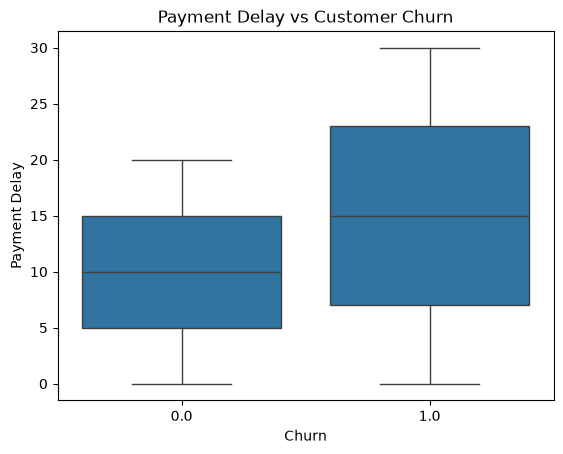

In [24]:
sns.boxplot(data=df, x="Churn", y="Payment Delay")

plt.title("Payment Delay vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Payment Delay")

plt.show()

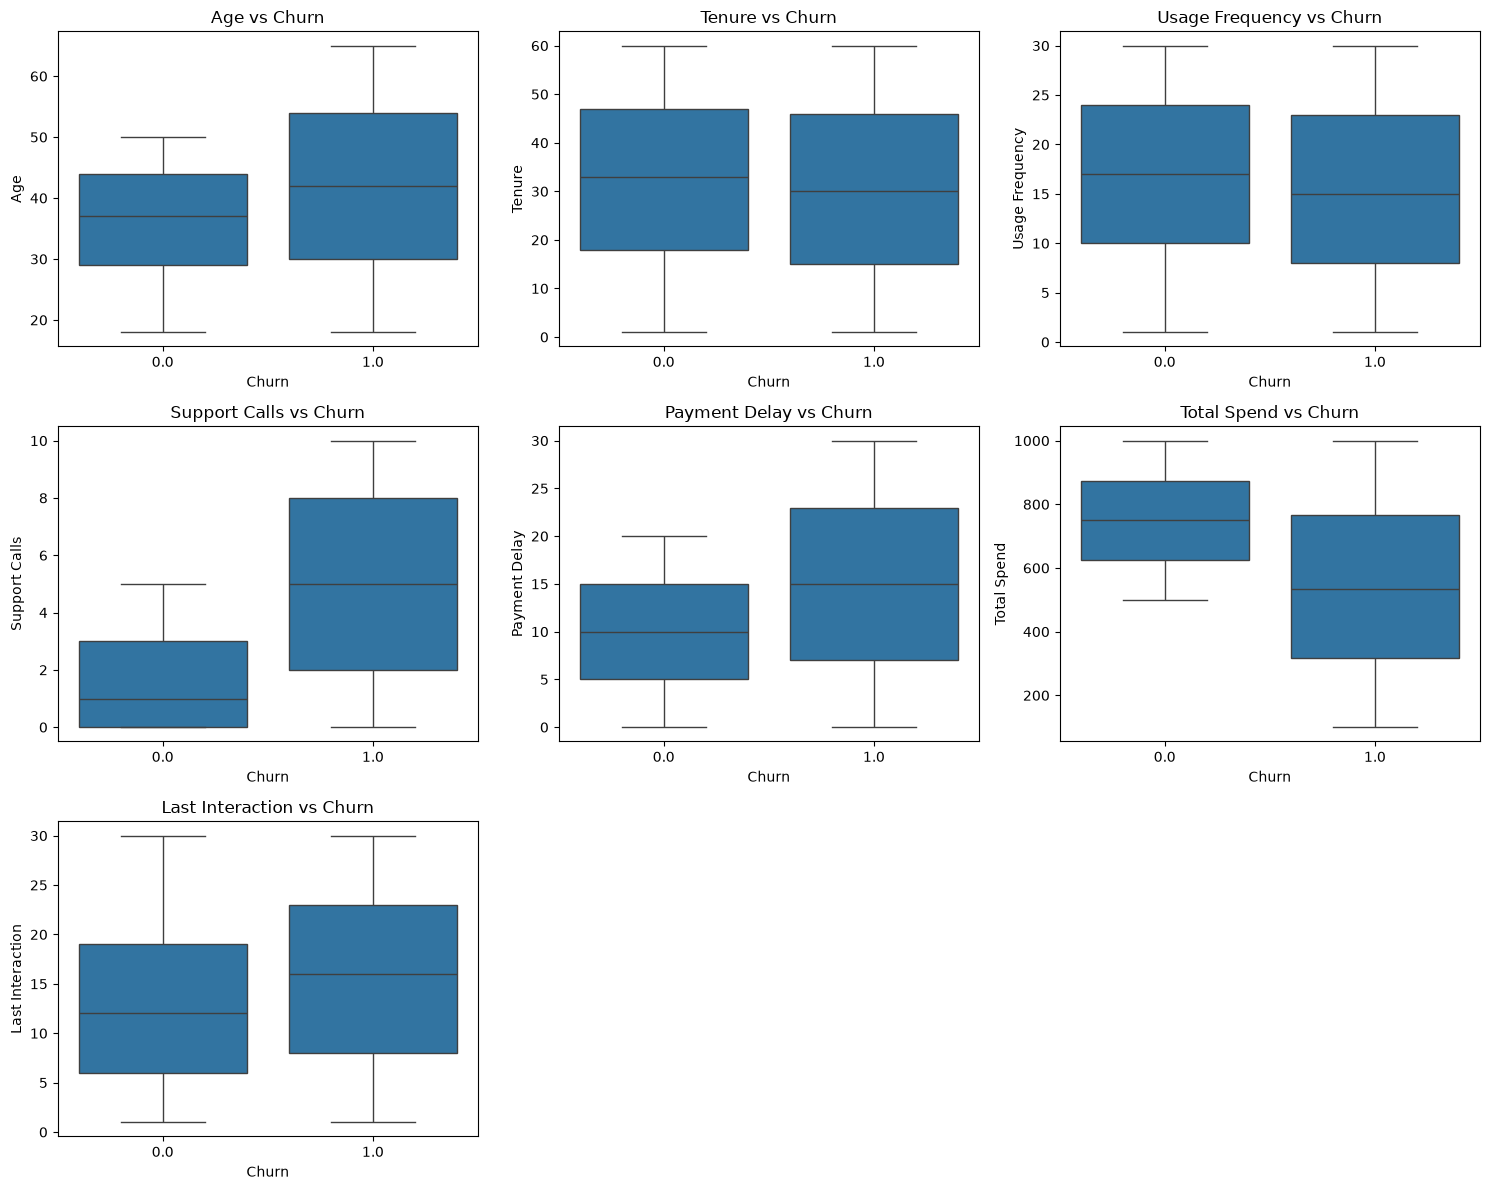

In [25]:
numeric_features = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(
        data=df,
        x="Churn",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} vs Churn")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(feature)


for i in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [26]:
for col in categorical_columns:
    churn_rate = df.groupby(col)["Churn"].mean() * 100

    print(f"\n--- Churn Rate by {col} ---")
    print(churn_rate)


--- Churn Rate by Gender ---
Gender
Female    66.669115
Male      49.126880
Name: Churn, dtype: float64

--- Churn Rate by Subscription Type ---
Subscription Type
Basic       58.178233
Premium     55.941700
Standard    56.069953
Name: Churn, dtype: float64

--- Churn Rate by Contract Length ---
Contract Length
Annual        46.076141
Monthly      100.000000
Quarterly     46.025605
Name: Churn, dtype: float64


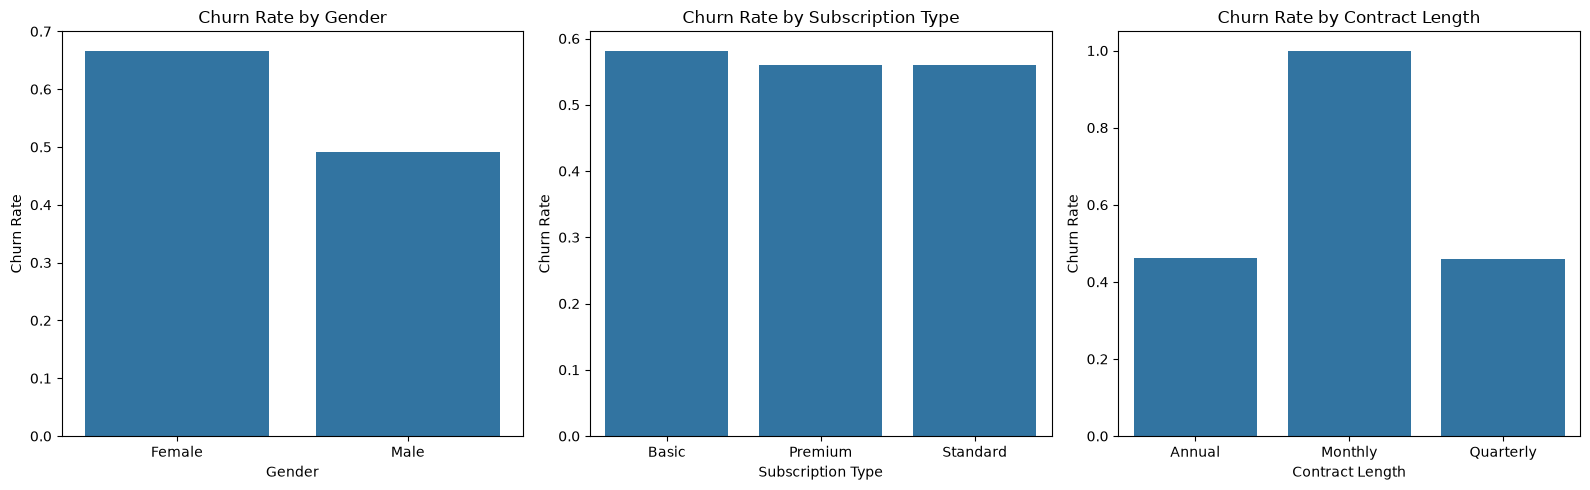

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(categorical_columns):

    churn_rate = (
        df.groupby(col)["Churn"]
        .mean()
        .reset_index()
    )

    sns.barplot(
        data=churn_rate,
        x=col,
        y="Churn",
        ax=axes[i]
    )

    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate")

plt.tight_layout()
plt.show()

In [28]:
pd.crosstab(
    df["Contract Length"],
    df["Churn"]
)

Churn,0.0,1.0
Contract Length,,
Annual,95552,81646
Monthly,0,87104
Quarterly,95281,81249


In [29]:
pd.crosstab(
    df["Contract Length"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0.0,1.0
Contract Length,,
Annual,53.923859,46.076141
Monthly,0.000000,100.000000
Quarterly,53.974395,46.025605


In [30]:
numeric_df = df.select_dtypes(include=["number"])

correlation_matrix = numeric_df.corr()

correlation_matrix

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
Age,1.000000,-0.011630,-0.007190,0.158451,0.061738,-0.084684,0.028980,0.218394
Tenure,-0.011630,1.000000,-0.026800,-0.027640,-0.016588,0.019006,-0.006903,-0.051919
Usage Frequency,-0.007190,-0.026800,1.000000,-0.022013,-0.014470,0.018631,-0.004662,-0.046101
Support Calls,0.158451,-0.027640,-0.022013,1.000000,0.162889,-0.221594,0.077684,0.574267
Payment Delay,0.061738,-0.016588,-0.014470,0.162889,1.000000,-0.121044,0.042708,0.312129
Total Spend,-0.084684,0.019006,0.018631,-0.221594,-0.121044,1.000000,-0.056890,-0.429355
Last Interaction,0.028980,-0.006903,-0.004662,0.077684,0.042708,-0.056890,1.000000,0.149616
Churn,0.218394,-0.051919,-0.046101,0.574267,0.312129,-0.429355,0.149616,1.000000


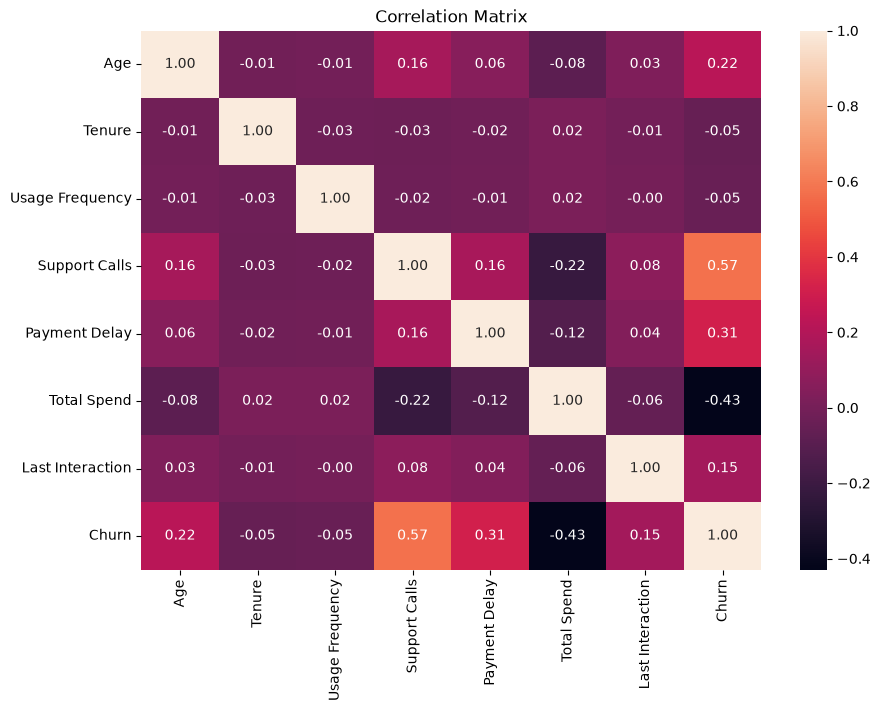

In [31]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()